In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"\n🖥️  GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("✅ Setup complete!")

Mounted at /content/drive

🖥️  GPU Available: True
GPU: Tesla T4
✅ Setup complete!


In [2]:
# Install required packages
!pip install torch torchvision -q
!pip install ultralytics -q
!pip install opencv-python -q
!pip install Pillow -q
!pip install scikit-learn -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("✅ All packages loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All packages loaded!


In [3]:
from pathlib import Path

# Base directory
BASE_DIR = Path('/content/drive/MyDrive/CamouflageDetection')

# Dataset paths
DATASET_DIR = BASE_DIR / '02_dataset'
YOLO_MODEL = BASE_DIR / '03_models/yolo_medium_improved/weights/best.pt'

# Output paths
RESNET_DIR = BASE_DIR / '03_models/resnet_verifier'
RESULTS_DIR = BASE_DIR / '04_results'

# Create directories
RESNET_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

print("📂 Paths configured:")
print(f"  YOLO model: {YOLO_MODEL.exists()}")
print(f"  Dataset: {DATASET_DIR.exists()}")
print(f"  Output: {RESNET_DIR}")

📂 Paths configured:
  YOLO model: True
  Dataset: True
  Output: /content/drive/MyDrive/CamouflageDetection/03_models/resnet_verifier


In [ ]:
print("="*70)
print("📦 STEP 1: CREATING TRAINING DATA FOR RESNET")
print("="*70)
print("Using YOLO to extract person crops + creating negative samples\n")

# Load YOLO model
from ultralytics import YOLO
yolo_model = YOLO(str(YOLO_MODEL))

# Create dataset directories
RESNET_DATA = BASE_DIR / '03_resnet_data'

# FIXED: Use 'train' and 'val' instead of 'test'
for split in ['train', 'val']:
    for category in ['person', 'not_person']:
        (RESNET_DATA / split / category).mkdir(parents=True, exist_ok=True)

print("✅ Directories created\n")

def create_resnet_dataset(images_dir, labels_dir, output_dir, split_name):
    """Extract person crops and create negative samples"""

    image_files = list(images_dir.glob('*.jpg'))

    print(f"Processing {split_name} set: {len(image_files)} images")

    person_count = 0
    non_person_count = 0

    for img_path in tqdm(image_files, desc=f"{split_name}"):
        # Read image
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        h, w = img.shape[:2]

        # Read YOLO labels
        label_path = labels_dir / (img_path.stem + '.txt')

        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue

                    cls, x_c, y_c, width, height = map(float, parts)

                    # Convert to pixels
                    x1 = int((x_c - width/2) * w)
                    y1 = int((y_c - height/2) * h)
                    x2 = int((x_c + width/2) * w)
                    y2 = int((y_c + height/2) * h)

                    # Ensure within bounds
                    x1 = max(0, min(x1, w-1))
                    y1 = max(0, min(y1, h-1))
                    x2 = max(0, min(x2, w))
                    y2 = max(0, min(y2, h))

                    # Crop person
                    if x2 > x1 and y2 > y1 and (x2-x1) > 20 and (y2-y1) > 20:
                        person_crop = img[y1:y2, x1:x2]

                        # Save
                        save_path = output_dir / split_name / 'person' / f"{img_path.stem}_{person_count}.jpg"
                        cv2.imwrite(str(save_path), person_crop)
                        person_count += 1

        # Create negative samples (backgrounds)
        for _ in range(2):
            crop_h = np.random.randint(50, 150)
            crop_w = np.random.randint(50, 150)

            if h > crop_h and w > crop_w:
                y = np.random.randint(0, h - crop_h)
                x = np.random.randint(0, w - crop_w)

                # Simple check: avoid person centers
                is_background = True

                if label_path.exists():
                    with open(label_path, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) != 5:
                                continue
                            cls, x_c, y_c, width, height = map(float, parts)

                            px = int(x_c * w)
                            py = int(y_c * h)

                            if x <= px <= x + crop_w and y <= py <= y + crop_h:
                                is_background = False
                                break

                if is_background:
                    bg_crop = img[y:y+crop_h, x:x+crop_w]
                    save_path = output_dir / split_name / 'not_person' / f"{img_path.stem}_bg_{non_person_count}.jpg"
                    cv2.imwrite(str(save_path), bg_crop)
                    non_person_count += 1

    print(f"✅ {split_name}: {person_count} person samples, {non_person_count} non-person samples")
    return person_count, non_person_count

# FIXED: Process train and test separately, save to 'train' and 'val'
import cv2
import numpy as np

# Training data from train set
train_pos, train_neg = create_resnet_dataset(
    DATASET_DIR / 'train/images',
    DATASET_DIR / 'train/labels',
    RESNET_DATA,
    'train'
)

# Validation data from test set
val_pos, val_neg = create_resnet_dataset(
    DATASET_DIR / 'test/images',
    DATASET_DIR / 'test/labels',
    RESNET_DATA,
    'val'  # ← FIXED: Changed from 'test' to 'val'
)

print("\n" + "="*70)
print("📊 DATASET SUMMARY")
print("="*70)
print(f"Training:   {train_pos} persons, {train_neg} non-persons")
print(f"Validation: {val_pos} persons, {val_neg} non-persons")
print("="*70)

📦 STEP 1: CREATING TRAINING DATA FOR RESNET
Using YOLO to extract person crops + creating negative samples

✅ Directories created

Processing train set: 748 images


train: 100%|██████████| 748/748 [00:49<00:00, 15.04it/s]


✅ train: 1078 person samples, 1450 non-person samples
Processing val set: 330 images


val: 100%|██████████| 330/330 [00:19<00:00, 16.93it/s]

✅ val: 418 person samples, 638 non-person samples

📊 DATASET SUMMARY
Training:   1078 persons, 1450 non-persons
Validation: 418 persons, 638 non-persons



📊 Visualizing training samples...


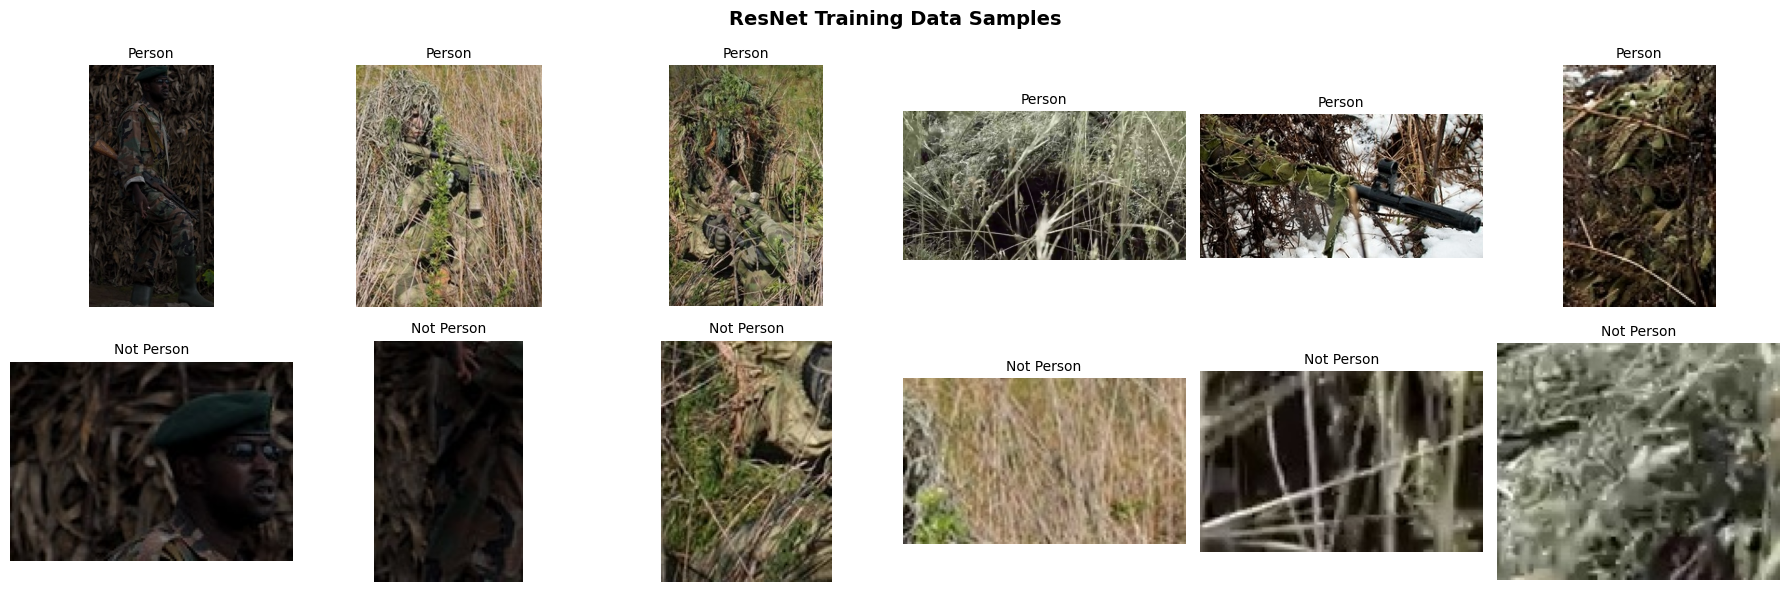

✅ Saved: /content/drive/MyDrive/CamouflageDetection/04_results/resnet_training_samples.png


In [ ]:
print("\n📊 Visualizing training samples...")

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Show person samples
person_dir = RESNET_DATA / 'train/person'
person_samples = list(person_dir.glob('*.jpg'))[:6]

for idx, img_path in enumerate(person_samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, idx].imshow(img)
    axes[0, idx].set_title('Person', fontsize=10)
    axes[0, idx].axis('off')

# Show non-person samples
non_person_dir = RESNET_DATA / 'train/not_person'
non_person_samples = list(non_person_dir.glob('*.jpg'))[:6]

for idx, img_path in enumerate(non_person_samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, idx].imshow(img)
    axes[1, idx].set_title('Not Person', fontsize=10)
    axes[1, idx].axis('off')

plt.suptitle('ResNet Training Data Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'resnet_training_samples.png', dpi=150)
plt.show()

print(f"✅ Saved: {RESULTS_DIR / 'resnet_training_samples.png'}")

In [ ]:
print("="*70)
print("🏗️  STEP 2: DEFINING RESNET50 MODEL")
print("="*70)

class ResNetVerifier(nn.Module):
    """ResNet50 binary classifier: Person vs Not Person"""

    def __init__(self, num_classes=2):
        super(ResNetVerifier, self).__init__()

        # Load pre-trained ResNet50
        self.resnet = models.resnet50(pretrained=True)

        # Freeze early layers (only fine-tune later layers)
        for param in list(self.resnet.parameters())[:-20]:
            param.requires_grad = False

        # Replace final layer for binary classification
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNetVerifier(num_classes=2).to(device)

print(f"✅ Model created on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

🏗️  STEP 2: DEFINING RESNET50 MODEL
✅ Model created on cuda
Total parameters: 24,558,146
Trainable parameters: 9,975,298


In [ ]:
print("\n📦 Setting up data loaders...")

# Data transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(
    root=str(RESNET_DATA / 'train'),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=str(RESNET_DATA / 'val'),
    transform=val_transform
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Validation samples: {len(val_dataset)}")
print(f"✅ Classes: {train_dataset.classes}")


📦 Setting up data loaders...
✅ Training samples: 5050
✅ Validation samples: 1056
✅ Classes: ['not_person', 'person']


In [ ]:
print("="*70)
print("🚀 STEP 3: TRAINING RESNET VERIFIER")
print("="*70)
print("This will take 45-60 minutes\n")

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ✅ FIXED: removed verbose argument
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=3
)

# Training parameters
num_epochs = 30
best_val_acc = 0.0

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Track learning rate manually
prev_lr = optimizer.param_groups[0]['lr']

# Training loop
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100.0 * train_correct / train_total

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100.0 * val_correct / val_total

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print metrics
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # ================= LR SCHEDULER =================
    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    if current_lr != prev_lr:
        print(f"📉 Learning rate reduced to {current_lr}")
        prev_lr = current_lr

    # ================= SAVE BEST MODEL =================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), RESNET_DIR / 'resnet_verifier_best.pth')
        print(f"✅ Saved best model! (Val Acc: {val_acc:.2f}%)")

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print(f"🏆 Best Validation Accuracy: {best_val_acc:.2f}%")


🚀 STEP 3: TRAINING RESNET VERIFIER
This will take 45-60 minutes


Epoch 1/30
--------------------------------------------------


Validation: 100%|██████████| 33/33 [00:07<00:00,  4.39it/s]


Train Loss: 0.3326 | Train Acc: 85.98%
Val Loss: 0.2413 | Val Acc: 89.96%
✅ Saved best model! (Val Acc: 89.96%)

Epoch 2/30
--------------------------------------------------


Validation: 100%|██████████| 33/33 [00:06<00:00,  5.30it/s]


Train Loss: 0.2215 | Train Acc: 91.49%
Val Loss: 0.2104 | Val Acc: 92.52%
✅ Saved best model! (Val Acc: 92.52%)

Epoch 3/30
--------------------------------------------------


...

Train Loss: 0.0122 | Train Acc: 99.62%
Val Loss: 0.3251 | Val Acc: 93.37%

Epoch 29/30
--------------------------------------------------


Validation: 100%|██████████| 33/33 [00:06<00:00,  4.97it/s]


Train Loss: 0.0121 | Train Acc: 99.60%
Val Loss: 0.3411 | Val Acc: 93.28%

Epoch 30/30
--------------------------------------------------


Validation: 100%|██████████| 33/33 [00:07<00:00,  4.54it/s]

Train Loss: 0.0154 | Train Acc: 99.43%
Val Loss: 0.3319 | Val Acc: 93.56%
📉 Learning rate reduced to 1.0000000000000004e-08

✅ TRAINING COMPLETE!
🏆 Best Validation Accuracy: 93.94%



📊 Plotting training history...


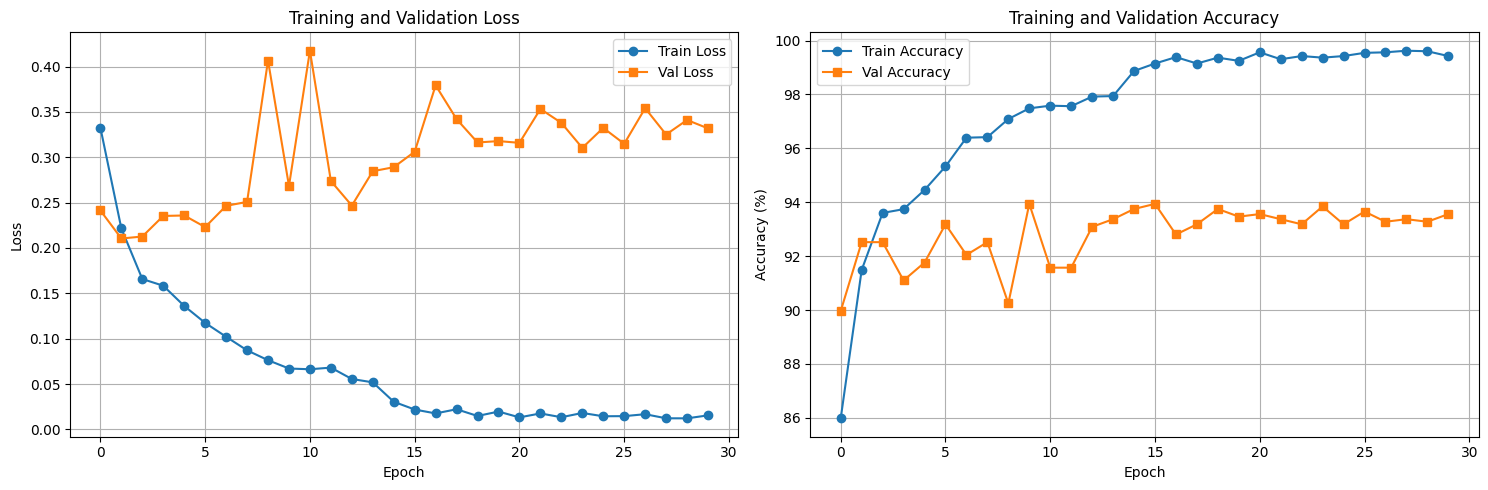

✅ Saved: /content/drive/MyDrive/CamouflageDetection/04_results/resnet_training_history.png


In [ ]:
print("\n📊 Plotting training history...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['val_acc'], label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'resnet_training_history.png', dpi=150)
plt.show()

print(f"✅ Saved: {RESULTS_DIR / 'resnet_training_history.png'}")

📊 EVALUATING RESNET VERIFIER


Evaluating: 100%|██████████| 33/33 [00:13<00:00,  2.52it/s]



📋 Classification Report:
              precision    recall  f1-score   support

  Not Person       0.94      0.96      0.95       638
      Person       0.93      0.91      0.92       418

    accuracy                           0.94      1056
   macro avg       0.94      0.93      0.94      1056
weighted avg       0.94      0.94      0.94      1056


📊 Confusion Matrix:
[[611  27]
 [ 37 381]]


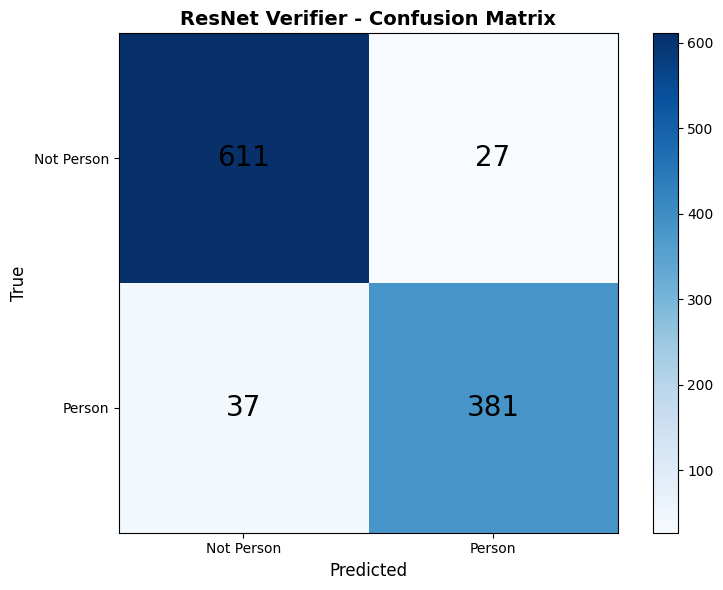


✅ Saved: /content/drive/MyDrive/CamouflageDetection/04_results/resnet_confusion_matrix.png


In [ ]:
print("="*70)
print("📊 EVALUATING RESNET VERIFIER")
print("="*70)

# Load best model
model.load_state_dict(torch.load(RESNET_DIR / 'resnet_verifier_best.pth'))
model.eval()

# Collect predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Evaluating"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("\n📋 Classification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=['Not Person', 'Person']
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\n📊 Confusion Matrix:")
print(cm)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Person', 'Person'])
ax.set_yticklabels(['Not Person', 'Person'])

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=20)

ax.set_title('ResNet Verifier - Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'resnet_confusion_matrix.png', dpi=150)
plt.show()

print(f"\n✅ Saved: {RESULTS_DIR / 'resnet_confusion_matrix.png'}")

In [ ]:
# Calculate final metrics
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

summary = f"""
{'='*70}
RESNET VERIFIER TRAINING SUMMARY
{'='*70}

MODEL: ResNet50 Fine-tuned for Binary Classification

DATASET:
- Training samples: {len(train_dataset)}
- Validation samples: {len(val_dataset)}
- Classes: Person, Not Person

TRAINING:
- Epochs: {num_epochs}
- Best Validation Accuracy: {best_val_acc:.2f}%

FINAL PERFORMANCE:
- Accuracy: {accuracy*100:.2f}%
- Precision: {precision*100:.2f}%
- Recall: {recall*100:.2f}%
- F1-Score: {f1*100:.2f}%

MODEL SAVED AT:
{RESNET_DIR / 'resnet_verifier_best.pth'}

PURPOSE:
- Filters YOLO false positives
- Verifies detected regions are actually persons
- Improves overall system precision

NEXT STEPS:
1. ✅ ResNet trained successfully
2. → Integrate with YOLO (Notebook 04)
3. → Add XAI explainability
4. → Test complete system
{'='*70}
"""

summary_path = RESULTS_DIR / 'resnet_training_summary.txt'
with open(summary_path, 'w') as f:
    f.write(summary)

print(summary)
print(f"\n✅ Summary saved: {summary_path}")

print("\n" + "="*70)
print("🎉 RESNET VERIFIER READY!")
print("="*70)
print("\nNext: Integrate YOLO + ResNet for complete detection system!")


RESNET VERIFIER TRAINING SUMMARY

MODEL: ResNet50 Fine-tuned for Binary Classification

DATASET:
- Training samples: 5050
- Validation samples: 1056
- Classes: Person, Not Person

TRAINING:
- Epochs: 30
- Best Validation Accuracy: 93.94%

FINAL PERFORMANCE:
- Accuracy: 93.94%
- Precision: 93.93%
- Recall: 93.94%
- F1-Score: 93.93%

MODEL SAVED AT:
/content/drive/MyDrive/CamouflageDetection/03_models/resnet_verifier/resnet_verifier_best.pth

PURPOSE:
- Filters YOLO false positives
- Verifies detected regions are actually persons
- Improves overall system precision

NEXT STEPS:
1. ✅ ResNet trained successfully
2. → Integrate with YOLO (Notebook 04)
3. → Add XAI explainability
4. → Test complete system


✅ Summary saved: /content/drive/MyDrive/CamouflageDetection/04_results/resnet_training_summary.txt

🎉 RESNET VERIFIER READY!

Next: Integrate YOLO + ResNet for complete detection system!


In [4]:
# ✅ AUTO-EXPORT RESNET RESULTS
print("💾 Saving ResNet results to CSV...")

import pandas as pd

resnet_results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [0.9394, 0.9393, 0.9394, 0.9393]
}

df = pd.DataFrame(resnet_results)
output_path = RESNET_DIR / 'resnet_metrics.csv'
df.to_csv(output_path, index=False)

print(f"✅ ResNet results saved to: {output_path}")
print(df.to_string(index=False))

💾 Saving ResNet results to CSV...
✅ ResNet results saved to: /content/drive/MyDrive/CamouflageDetection/03_models/resnet_verifier/resnet_metrics.csv
   Metric  Value
 Accuracy 0.9394
Precision 0.9393
   Recall 0.9394
 F1-Score 0.9393
